In [2]:
import json
import pickle
import numpy as np
import matplotlib.pyplot as plt
import os
from tqdm import tqdm

import pandas as pd
from scipy.stats import ttest_rel, sem, pearsonr
import seaborn as sns

from sem_sup_sparse_code_mp_clean import LinearGenerativeClassifier, KEYS

In [3]:
results = {}

duration = []
params = []
all_val_curves, all_ood_curves = [], []
all_val_curves_ve, all_ood_curves_ve = [], []
all_val_curves_logreg, all_ood_curves_logreg = [], []
all_val_curves_gencla, all_ood_curves_gencla = [], []

for key in KEYS:
    print(key)
    results[key] = {'auc': {}, 'acc': {}}
    directory = os.path.join('results/exp2_reproduce', key)
    
    LinReg_auc_iid_val, LinReg_auc_ood = [], []
    GenCla_auc_iid_val, GenCla_auc_ood = [], []
    SparseCode_auc_iid_val, SparseCode_auc_ood = [], []
    
    LinReg_acc_iid_val, LinReg_acc_ood = [], []
    GenCla_acc_iid_val, GenCla_acc_ood = [], []
    SparseCode_acc_iid_val, SparseCode_acc_ood = [], []
    
    runs = [_ for _ in os.listdir(directory)]
    seeds = np.unique([_.split('_')[1] for _ in runs])[:]
    for seed in tqdm(seeds):
        LinReg_auc_iid_val_seed, LinReg_auc_ood_seed = [], []
        GenCla_auc_iid_val_seed, GenCla_auc_ood_seed = [], []
        SparseCode_auc_iid_val_seed, SparseCode_auc_ood_seed = [], []
        
        LinReg_acc_iid_val_seed, LinReg_acc_ood_seed = [], []
        GenCla_acc_iid_val_seed, GenCla_acc_ood_seed = [], []
        SparseCode_acc_iid_val_seed, SparseCode_acc_ood_seed = [], []
        try:
            for rep in range(5):
                file_path = os.path.join(directory, f'seed_{seed}_rep_{rep}')
                with open(file_path + '/log.pickle', 'rb') as handle:
                    log = pickle.load(handle)
                    
                with open(file_path + '/params.json', 'r') as f:
                    params.append(eval(f.read()))

                duration.append(len(log['SpaCod_auc_iid_val']))
        
                LinReg_auc_iid_val_seed.append(log['LinReg_auc_iid_val'])
                LinReg_auc_ood_seed.append(log['LinReg_auc_ood'])
                GenCla_auc_iid_val_seed.append(log['GenCla_auc_iid_val'])
                GenCla_auc_ood_seed.append(log['GenCla_auc_ood'])
                
                best = np.argmax(log['SpaCod_auc_iid_val'])
                
                SparseCode_auc_iid_val_seed.append(log['SpaCod_auc_iid_val'][best])
                SparseCode_auc_ood_seed.append(log['SpaCod_auc_ood'][best])
                
                LinReg_acc_iid_val_seed.append(log['LinReg_acc_iid_val'])
                LinReg_acc_ood_seed.append(log['LinReg_acc_ood'])
                GenCla_acc_iid_val_seed.append(log['GenCla_acc_iid_val'])
                GenCla_acc_ood_seed.append(log['GenCla_acc_ood'])
                
                best = np.argmax(log['SpaCod_acc_iid_val'])
                
                SparseCode_acc_iid_val_seed.append(log['SpaCod_acc_iid_val'][best])
                SparseCode_acc_ood_seed.append(log['SpaCod_acc_ood'][best])

                all_val_curves.append(log['SpaCod_auc_iid_val'])
                all_ood_curves.append(log['SpaCod_auc_ood'])
                all_val_curves_ve.append(log['var_exp_iid_val'])
                all_ood_curves_ve.append(log['var_exp_ood'])

                all_val_curves_logreg.append(log['LinReg_auc_iid_val'])
                all_ood_curves_logreg.append(log['LinReg_auc_ood'])

                all_val_curves_gencla.append(log['GenCla_auc_iid_val'])
                all_ood_curves_gencla.append(log['GenCla_auc_ood'])

            LinReg_auc_iid_val.append(LinReg_auc_iid_val_seed)
            LinReg_auc_ood.append(LinReg_auc_ood_seed)
            GenCla_auc_iid_val.append(GenCla_auc_iid_val_seed)
            GenCla_auc_ood.append(GenCla_auc_ood_seed)
            SparseCode_auc_iid_val.append(SparseCode_auc_iid_val_seed)
            SparseCode_auc_ood.append(SparseCode_auc_ood_seed)

            LinReg_acc_iid_val.append(LinReg_acc_iid_val_seed)
            LinReg_acc_ood.append(LinReg_acc_ood_seed)
            GenCla_acc_iid_val.append(GenCla_acc_iid_val_seed)
            GenCla_acc_ood.append(GenCla_acc_ood_seed)
            SparseCode_acc_iid_val.append(SparseCode_acc_iid_val_seed)
            SparseCode_acc_ood.append(SparseCode_acc_ood_seed)
            # print(key, seed, 'complete')
        except FileNotFoundError:
            pass
    results[key]['auc']['LinReg_iid_val'] = np.array(LinReg_auc_iid_val)
    results[key]['auc']['LinReg_ood'] = np.array(LinReg_auc_ood)
    results[key]['auc']['GenCla_iid_val'] = np.array(GenCla_auc_iid_val)
    results[key]['auc']['GenCla_ood'] = np.array(GenCla_auc_ood)
    results[key]['auc']['SparseCode_iid_val'] = np.array(SparseCode_auc_iid_val)
    results[key]['auc']['SparseCode_ood'] = np.array(SparseCode_auc_ood)
    
    results[key]['acc']['LinReg_iid_val'] = np.array(LinReg_acc_iid_val)
    results[key]['acc']['LinReg_ood'] = np.array(LinReg_acc_ood)
    results[key]['acc']['GenCla_iid_val'] = np.array(GenCla_acc_iid_val)
    results[key]['acc']['GenCla_ood'] = np.array(GenCla_acc_ood)
    results[key]['acc']['SparseCode_iid_val'] = np.array(SparseCode_acc_iid_val)
    results[key]['acc']['SparseCode_ood'] = np.array(SparseCode_acc_ood)
    
    print('\n')

5_hist_fig_ismale


100%|██████████| 26/26 [00:15<00:00,  1.69it/s]




6_hist_fig_isamerican


100%|██████████| 30/30 [00:17<00:00,  1.70it/s]




7_hist_fig_ispolitician


...

100%|██████████| 30/30 [00:12<00:00,  2.32it/s]




87_glue_cola


100%|██████████| 30/30 [00:16<00:00,  1.82it/s]




90_glue_qnli


100%|██████████| 30/30 [00:16<00:00,  1.80it/s]

In [4]:
for key in results:
    print(key, results[key]['acc']['LinReg_iid_val'].shape)

5_hist_fig_ismale (25, 5)
6_hist_fig_isamerican (30, 5)
7_hist_fig_ispolitician (30, 5)
66_living-room (30, 5)
67_social-security (30, 5)
73_control-group (30, 5)
87_glue_cola (30, 5)
90_glue_qnli (30, 5)


acc


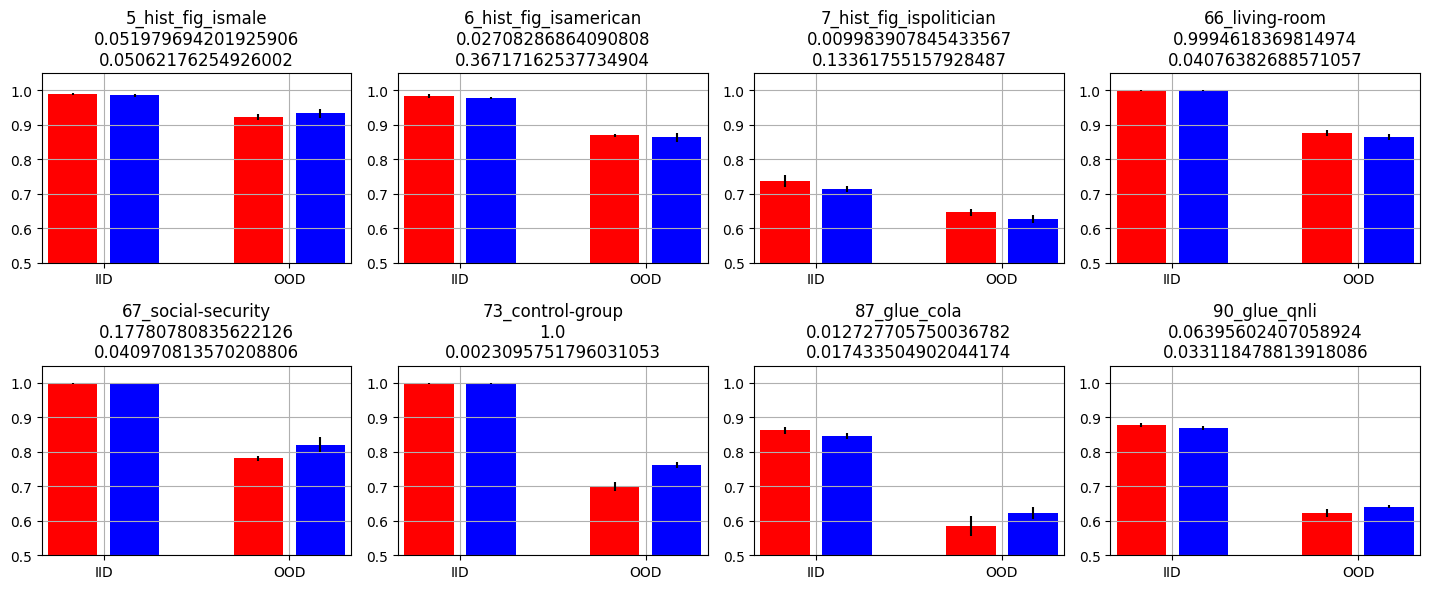

auc


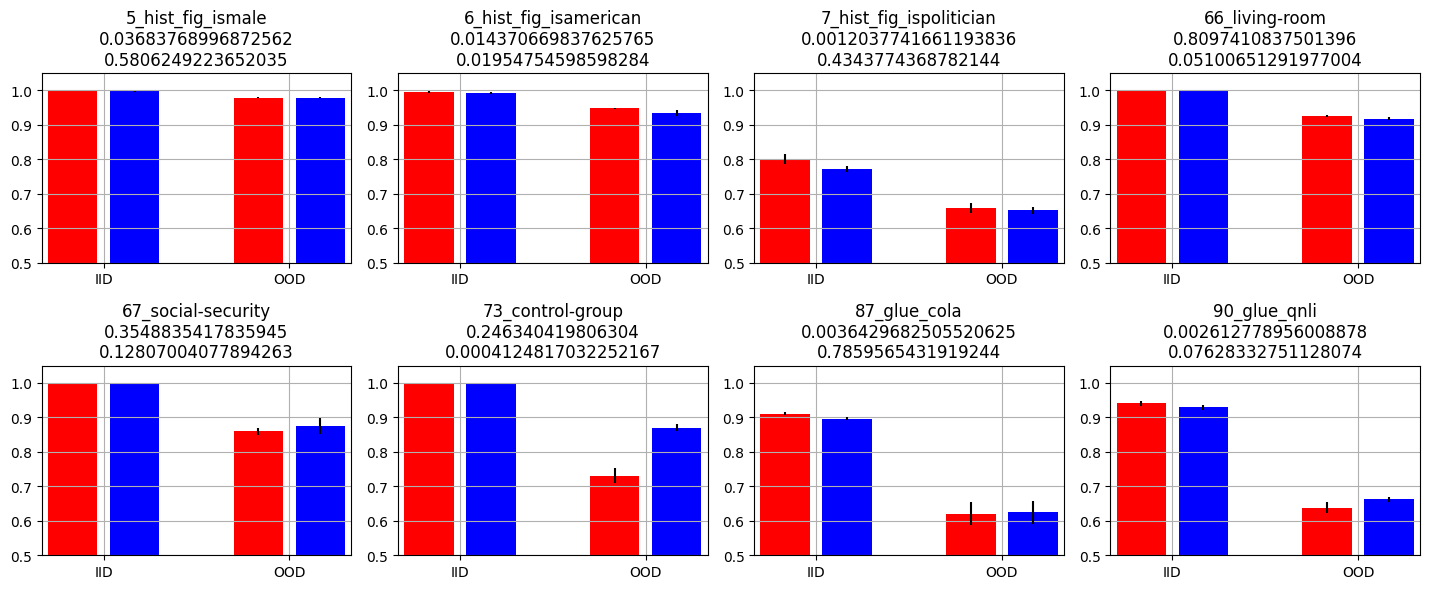

In [5]:
a, b, c, d = [], [], [], []
a_full, b_full, c_full, d_full = [], [], [], []
for metric in ['acc', 'auc']:
    print(metric)
    plt.figure(figsize=1.2 * np.array((12, 5)))
    for i, key in enumerate(results):
        best_lr = np.argmax(results[key][metric]['LinReg_iid_val'].mean(1))
        LinReg_iid_val = results[key][metric]['LinReg_iid_val'][best_lr]
        LinReg_ood = results[key][metric]['LinReg_ood'][best_lr]
        
        best_sc = np.argmax(results[key][metric]['SparseCode_iid_val'].mean(1))                
        SparseCode_iid_val = results[key][metric]['SparseCode_iid_val'][best_sc]
        SparseCode_ood = results[key][metric]['SparseCode_ood'][best_sc]
        
        plt.subplot(2, 4, i + 1)
        plt.title(
            key +\
            '\n%s' % ttest_rel(LinReg_iid_val, SparseCode_iid_val)[1] +\
            '\n%s' % ttest_rel(LinReg_ood, SparseCode_ood)[1]
         )
        plt.bar(
            x=[-.5, 2.5],
            height=[
                np.mean(LinReg_iid_val), 
                np.mean(LinReg_ood)
            ], 
            yerr=[
                np.std(LinReg_iid_val),
                np.std(LinReg_ood)
            ],
            color='red',
            label='Logistic\nRegression'
        )
        plt.bar(
            x=[.5, 3.5],
            height=[
                np.mean(SparseCode_iid_val), 
                np.mean(SparseCode_ood)
            ], 
            yerr=[
                np.std(SparseCode_iid_val),
                np.std(SparseCode_ood)
            ],
            color='blue',
            label='Sparse\nCoding'
        )

        if metric == 'auc':
            a.append(np.mean(LinReg_iid_val))
            b.append(np.mean(SparseCode_iid_val))
            c.append(np.mean(LinReg_ood))
            d.append(np.mean(SparseCode_ood))
            a_full.append(LinReg_iid_val)
            b_full.append(SparseCode_iid_val)
            c_full.append(LinReg_ood)
            d_full.append(SparseCode_ood)
        
        plt.xticks([0, 3], ['IID', 'OOD'])
        # plt.legend(loc=4)
        plt.grid()
        plt.xlim(-1, 4)
        plt.ylim(0.5, 1.05)
    plt.tight_layout()
    plt.show()

In [6]:
def format_cell(mean_val, sem_val, is_bold=False):
    """Formats a single cell string as 'mean ± sem' with optional bolding."""
    cell_str = f"{mean_val:.4f} $\\pm$ {sem_val:.4f}"
    if is_bold:
        return f"\\textbf{{{cell_str}}}"
    return cell_str

def generate_latex_table(results_dict, metric):
    """
    Processes the results and generates a complete LaTeX table for a given metric,
    with datasets sorted numerically.
    
    Args:
        results_dict (dict): The nested dictionary containing your experimental results.
        metric (str): The metric to generate the table for ('acc' or 'auc').
    """
    records = []
    # 1. Data Wrangling: Convert the nested dict into a tidy DataFrame
    for dataset_key in results_dict:
        # Find the best hyperparameter set for each model based on IID validation performance
        best_lr_idx = np.argmax(results_dict[dataset_key][metric]['LinReg_iid_val'].mean(axis=1))
        best_sc_idx = np.argmax(results_dict[dataset_key][metric]['SparseCode_iid_val'].mean(axis=1))

        # Extract the 5 repetition scores for the best hyperparameters
        scores = {
            ('LinReg', 'IID'): results_dict[dataset_key][metric]['LinReg_iid_val'][best_lr_idx],
            ('LinReg', 'OOD'): results_dict[dataset_key][metric]['LinReg_ood'][best_lr_idx],
            ('SparseCode', 'IID'): results_dict[dataset_key][metric]['SparseCode_iid_val'][best_sc_idx],
            ('SparseCode', 'OOD'): results_dict[dataset_key][metric]['SparseCode_ood'][best_sc_idx],
        }
        
        for (model, condition), score_array in scores.items():
            for score in score_array:
                records.append({
                    "Dataset": dataset_key,
                    "Model": model,
                    "Condition": condition,
                    "Score": score
                })
    
    df = pd.DataFrame(records)

    # 2. Generate LaTeX table string
    latex_lines = []
    # Preamble and Header
    latex_lines.append("\\begin{table*}[t]")
    latex_lines.append("\\centering")
    latex_lines.append(f"\\caption{{Comparison of Model Performance ({metric.upper()})}}")
    latex_lines.append("\\label{tab:results_" + metric + "}")
    latex_lines.append("\\begin{tabular}{lcccc}")
    latex_lines.append("\\toprule")
    latex_lines.append("Dataset & \\multicolumn{2}{c}{IID Performance} & \\multicolumn{2}{c}{OOD Performance} \\\\")
    latex_lines.append("\\cmidrule(lr){2-3} \\cmidrule(lr){4-5}")
    latex_lines.append("& Logistic Regression & Sparse Coding & Logistic Regression & Sparse Coding \\\\")
    latex_lines.append("\\midrule")

    # 3. Sort dataset keys numerically
    try:
        # Sort based on the integer prefix in the key
        sorted_keys = sorted(results_dict.keys(), key=lambda k: int(k.split('_')[0]))
    except (ValueError, IndexError):
        # Fallback to alphabetical sort if keys don't have the expected integer prefix
        print(f"Warning: Could not sort datasets by integer prefix for LaTeX table '{metric}'. Using alphabetical sort.")
        sorted_keys = sorted(results_dict.keys())

    # 4. Table Body: Iterate through sorted datasets and populate rows
    for dataset_key in sorted_keys:
        group = df[df['Dataset'] == dataset_key]
        row_data = {'Dataset': dataset_key.replace('_', ' ').title()}
        
        for condition in ['IID', 'OOD']:
            # Get the scores for both models for the current dataset and condition
            lr_scores = group[(group['Model'] == 'LinReg') & (group['Condition'] == condition)]['Score']
            sc_scores = group[(group['Model'] == 'SparseCode') & (group['Condition'] == condition)]['Score']
            
            # Perform paired t-test
            _, p_value = ttest_rel(sc_scores, lr_scores)
            
            lr_mean, sc_mean = lr_scores.mean(), sc_scores.mean()
            lr_sem, sc_sem = sem(lr_scores), sem(sc_scores)

            # Determine which cell (if any) to make bold
            lr_is_bold = (p_value < 0.05) and (lr_mean > sc_mean)
            sc_is_bold = (p_value < 0.05) and (sc_mean > lr_mean)

            # Format the cell strings
            row_data[f'{condition}_LinReg'] = format_cell(lr_mean, lr_sem, lr_is_bold)
            row_data[f'{condition}_SparseCode'] = format_cell(sc_mean, sc_sem, sc_is_bold)

        # Append the formatted row to the table
        line = (f"{row_data['Dataset']} & {row_data['IID_LinReg']} & {row_data['IID_SparseCode']} & "
                f"{row_data['OOD_LinReg']} & {row_data['OOD_SparseCode']} \\\\")
        latex_lines.append(line)

    # 5. Footer
    latex_lines.append("\\bottomrule")
    latex_lines.append("\\end{tabular}")
    latex_lines.append("\\end{table*}")

    return "\n".join(latex_lines)

# --- Generate and print the LaTeX tables ---
print("--- LaTeX Table for ACCURACY ---")
print("Copy and paste the code below into your LaTeX document.")
print("You might need to add `\\usepackage{booktabs}` and `\\usepackage{amsmath}` to your preamble.\n")
latex_table_acc = generate_latex_table(results, 'acc')
print(latex_table_acc)

print("\n" + "="*50 + "\n")

print("--- LaTeX Table for AUC ---")
print("Copy and paste the code below into your LaTeX document.\n")
latex_table_auc = generate_latex_table(results, 'auc')
print(latex_table_auc)

--- LaTeX Table for ACCURACY ---
Copy and paste the code below into your LaTeX document.
You might need to add `\usepackage{booktabs}` and `\usepackage{amsmath}` to your preamble.

\begin{table*}[t]
\centering
\caption{Comparison of Model Performance (ACC)}
\label{tab:results_acc}
\begin{tabular}{lcccc}
\toprule
Dataset & \multicolumn{2}{c}{IID Performance} & \multicolumn{2}{c}{OOD Performance} \\
\cmidrule(lr){2-3} \cmidrule(lr){4-5}
& Logistic Regression & Sparse Coding & Logistic Regression & Sparse Coding \\
\midrule
5 Hist Fig Ismale & 0.9892 $\pm$ 0.0017 & 0.9862 $\pm$ 0.0023 & 0.9224 $\pm$ 0.0044 & 0.9331 $\pm$ 0.0069 \\
6 Hist Fig Isamerican & \textbf{0.9840 $\pm$ 0.0029} & 0.9780 $\pm$ 0.0018 & 0.8700 $\pm$ 0.0024 & 0.8640 $\pm$ 0.0062 \\
7 Hist Fig Ispolitician & \textbf{0.7378 $\pm$ 0.0091} & 0.7134 $\pm$ 0.0042 & 0.6467 $\pm$ 0.0051 & 0.6273 $\pm$ 0.0055 \\
66 Living-Room & 0.9994 $\pm$ 0.0004 & 0.9994 $\pm$ 0.0004 & \textbf{0.8773 $\pm$ 0.0045} & 0.8653 $\pm$ 0.0048 \\
67 

In [7]:
a = np.concatenate(a_full)
b = np.concatenate(b_full)
c = np.concatenate(c_full)
d = np.concatenate(d_full)

/tmp/12323766.1.gpu_ded.q/ipykernel_3401098/1140845488.py:96: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = plt.cm.get_cmap('tab10', len(df_scatter))


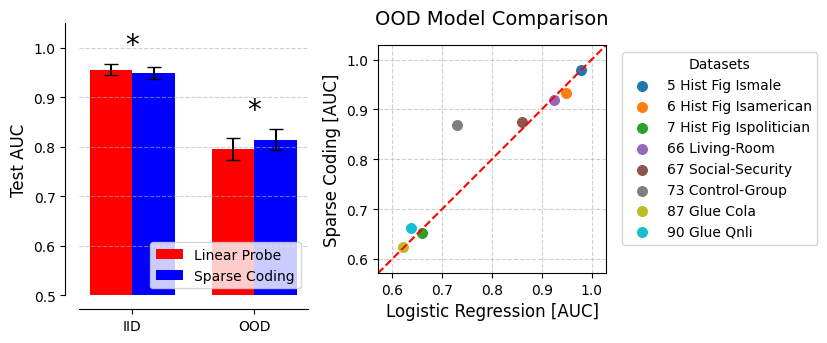

In [8]:
def create_summary_plots(results_dict):
    """
    Generates a figure with two subplots:
    1. A summary bar chart of mean IID and OOD AUC performance with significance indicators.
    2. A scatter plot comparing OOD AUC performance for each dataset.

    Args:
        results_dict (dict): The nested dictionary with experimental results.
    """
    metric = 'auc'
    
    # --- Data Preparation for Both Plots ---
    lr_iid_scores_all, sc_iid_scores_all = [], []
    lr_ood_scores_all, sc_ood_scores_all = [], []
    plot_data_scatter = []

    # 1. Sort the datasets by the integer prefix in their key
    try:
        sorted_items = sorted(results_dict.items(), key=lambda item: int(item[0].split('_')[0]))
    except (ValueError, IndexError):
        print("Warning: Could not sort datasets by integer prefix. Using alphabetical sort.")
        sorted_items = sorted(results_dict.items())

    # 2. Extract and process data for each dataset
    for dataset_key, data in sorted_items:
        best_lr_idx = np.argmax(data[metric]['LinReg_iid_val'].mean(axis=1))
        best_sc_idx = np.argmax(data[metric]['SparseCode_iid_val'].mean(axis=1))
        
        lr_ood_scores = data[metric]['LinReg_ood'][best_lr_idx]
        sc_ood_scores = data[metric]['SparseCode_ood'][best_sc_idx]
        lr_iid_scores = data[metric]['LinReg_iid_val'][best_lr_idx]
        sc_iid_scores = data[metric]['SparseCode_iid_val'][best_sc_idx]

        # Data for bar plot (aggregate all scores)
        lr_iid_scores_all.extend(lr_iid_scores)
        sc_iid_scores_all.extend(sc_iid_scores)
        lr_ood_scores_all.extend(lr_ood_scores)
        sc_ood_scores_all.extend(sc_ood_scores)

        # Data for scatter plot
        plot_data_scatter.append({
            "dataset": dataset_key.replace('_', ' ').title(),
            "lr_mean": np.mean(lr_ood_scores),
            "sc_mean": np.mean(sc_ood_scores)
        })

    df_scatter = pd.DataFrame(plot_data_scatter)

    # --- Plotting ---
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=.7 * np.array((12, 5.5)))

    # --- Subplot 1: Polished Bar Chart ---
    bar_positions = np.array([0, 1])
    bar_width = 0.35
    
    means = {
        'Linear Probe': [np.mean(lr_iid_scores_all), np.mean(lr_ood_scores_all)],
        'Sparse Coding': [np.mean(sc_iid_scores_all), np.mean(sc_ood_scores_all)]
    }
    sems = {
        'Linear Probe': [sem(lr_iid_scores_all), sem(lr_ood_scores_all)],
        'Sparse Coding': [sem(sc_iid_scores_all), sem(sc_ood_scores_all)]
    }
    
    ax1.bar(bar_positions - bar_width/2, means['Linear Probe'], yerr=sems['Linear Probe'], 
            width=bar_width, label='Linear Probe', color='red', capsize=5)
    ax1.bar(bar_positions + bar_width/2, means['Sparse Coding'], yerr=sems['Sparse Coding'], 
            width=bar_width, label='Sparse Coding', color='blue', capsize=5)

    # Add significance asterisks
    for i, condition in enumerate(['IID', 'OOD']):
        if condition == 'IID':
            # p_value = ttest_rel(lr_iid_scores_all, sc_iid_scores_all).pvalue
            p_value = ttest_rel(a, b).pvalue
        else: # OOD
            # p_value = ttest_rel(lr_ood_scores_all, sc_ood_scores_all).pvalue
            p_value = ttest_rel(c, d).pvalue
        
        if p_value < 0.05:
            y1 = means['Linear Probe'][i] + sems['Linear Probe'][i]
            y2 = means['Sparse Coding'][i] + sems['Sparse Coding'][i]
            y_max = max(y1, y2)
            ax1.text(bar_positions[i], y_max + 0.01, '*', ha='center', va='bottom', fontsize=20, color='black')

    ax1.set_ylabel('Test AUC', fontsize=12)
    ax1.set_xticks(bar_positions)
    ax1.set_xticklabels(['IID', 'OOD'], fontsize=12)
    # ax1.set_title('Average Model Performance', fontsize=14, pad=15)
    ax1.legend(loc='lower right')
    ax1.grid(True, linestyle='--', alpha=0.6, axis='y')
    ax1.set_ylim(0.5, 1.05) # Adjusted ylim for asterisk
    sns.despine(ax=ax1, offset=10)


    # --- Subplot 2: OOD Scatter Plot ---
    colors = plt.cm.get_cmap('tab10', len(df_scatter))

    for i, row in df_scatter.iterrows():
        ax2.scatter(
            x=row['lr_mean'], y=row['sc_mean'],
            color=colors(i), s=80,
            edgecolors='white', label=row['dataset']
        )

    min_val = df_scatter[['lr_mean', 'sc_mean']].min().min() - 0.05
    max_val = df_scatter[['lr_mean', 'sc_mean']].max().max() + 0.05
    ax2.plot([min_val, max_val], [min_val, max_val], 'r--', label='_nolegend_')

    ax2.set_xlabel('Logistic Regression [AUC]', fontsize=12)
    ax2.set_ylabel('Sparse Coding [AUC]', fontsize=12)
    ax2.set_title('OOD Model Comparison', fontsize=14, pad=15)
    ax2.set_xlim(min_val, max_val)
    ax2.set_ylim(min_val, max_val)
    ax2.set_aspect('equal', adjustable='box')
    ax2.grid(True, linestyle='--', alpha=0.6)
    
    ax2.legend(title="Datasets", bbox_to_anchor=(1.04, 1), loc='upper left')

    # Adjust overall layout
    fig.tight_layout()#rect=[0, 0, 0.85, 1])
    # plt.savefig('fig_real_data.pdf')
    plt.show()

    
create_summary_plots(results)